In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

In [2]:
batch_size = 100

# MNIST Dataset
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))
])

train_dataset = torchvision.datasets.MNIST(root='./mnist_data/', train= True, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset= train_dataset, batch_size= batch_size, shuffle=True, num_workers=0)

100.0%
100.0%
100.0%
100.0%


In [3]:
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)
    
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))
    
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)
    
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        
        return torch.sigmoid(self.fc4(x))

In [8]:
z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator(g_input_dim=z_dim, g_output_dim=mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

C:\Users\Victor\AppData\Roaming\Python\Python312\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [9]:
criterion = torch.nn.BCELoss()

lr = 0.0002
G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)

In [16]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()
        
    return  D_loss.data.item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()
        
    return G_loss.data.item()

In [17]:
# Laço de treino.
n_epoch = 200
for epoch in range(1, n_epoch+1):           
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

[1/200]: loss_d: 0.758, loss_g: 3.588
[2/200]: loss_d: 1.047, loss_g: 1.940
[3/200]: loss_d: 0.922, loss_g: 1.931
[4/200]: loss_d: 0.802, loss_g: 2.441
[5/200]: loss_d: 0.628, loss_g: 2.316
[6/200]: loss_d: 0.463, loss_g: 2.988
[7/200]: loss_d: 0.577, loss_g: 2.570
[8/200]: loss_d: 0.588, loss_g: 2.435
[9/200]: loss_d: 0.635, loss_g: 2.257
[10/200]: loss_d: 0.622, loss_g: 2.366
[11/200]: loss_d: 0.701, loss_g: 2.160
[12/200]: loss_d: 0.667, loss_g: 2.247
[13/200]: loss_d: 0.721, loss_g: 2.115
[14/200]: loss_d: 0.743, loss_g: 1.934
[15/200]: loss_d: 0.807, loss_g: 1.849
[16/200]: loss_d: 0.784, loss_g: 1.826
[17/200]: loss_d: 0.802, loss_g: 1.842
[18/200]: loss_d: 0.826, loss_g: 1.764
[19/200]: loss_d: 0.839, loss_g: 1.741
[20/200]: loss_d: 0.891, loss_g: 1.628
[21/200]: loss_d: 0.942, loss_g: 1.523
[22/200]: loss_d: 0.890, loss_g: 1.607
[23/200]: loss_d: 0.936, loss_g: 1.549
[24/200]: loss_d: 0.928, loss_g: 1.542
[25/200]: loss_d: 0.951, loss_g: 1.527
[26/200]: loss_d: 0.977, loss_g: 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


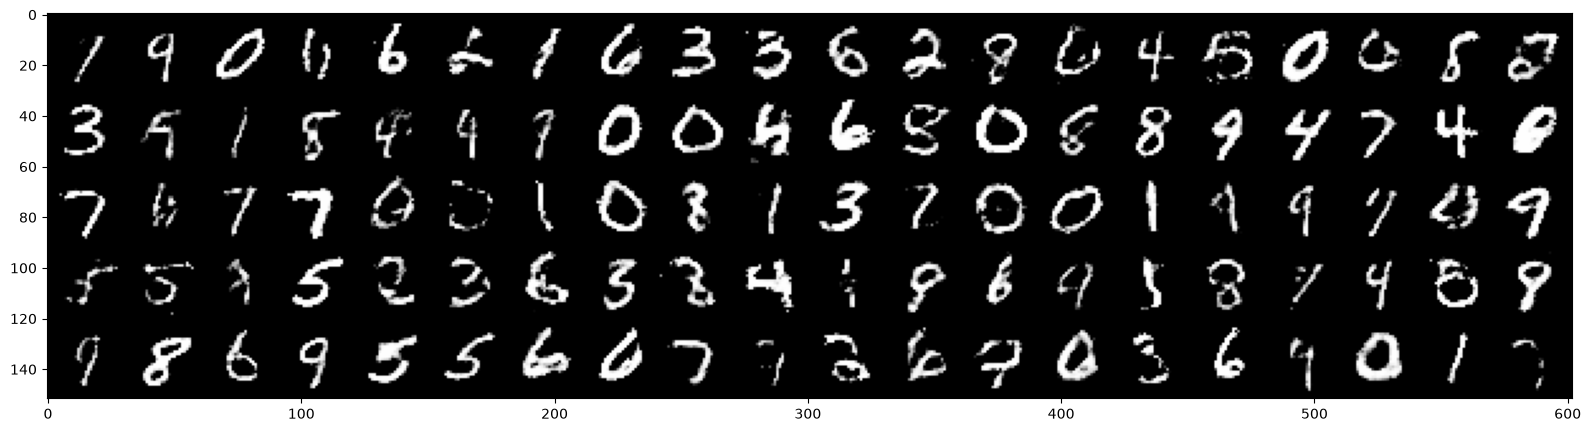

In [18]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')

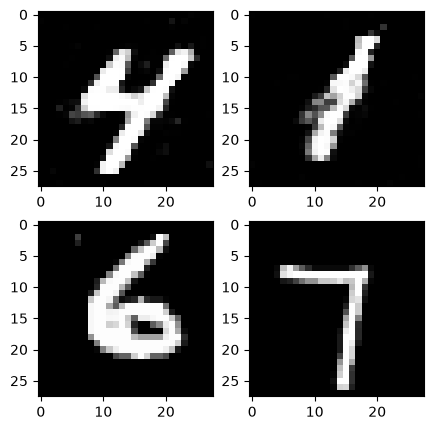

In [19]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[0]].transpose(1, 2, 0), cmap="gray")
axes[0, 1].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[1]].transpose(1, 2, 0), cmap="gray")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].numpy().transpose(1,2,0), cmap="gray")